# Lab 2: Decision Trees

In [1]:
#imports
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
# helper functions
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (8, 5.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DATA_PATH = Path("kyphosis.csv")
CLASS_ORDER = ["absent", "present"]
CLASS_PALETTE = {"absent": "#4C78A8", "present": "#E45756"}


def report_frame(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return pd.DataFrame(report).T


def summary_row(name, y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {
        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision (present)": report["present"]["precision"],
        "Recall (present)": report["present"]["recall"],
        "F1 (present)": report["present"]["f1-score"],
    }


def plot_confusion(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_ORDER)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=sns.light_palette("#4C78A8", as_cmap=True),
        cbar=False,
        square=True,
        linewidths=1,
        linecolor="white",
        ax=ax,
    )
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
    ax.set_xticklabels(CLASS_ORDER)
    ax.set_yticklabels(CLASS_ORDER, rotation=0)

## Load and inspect the dataset

In [3]:
df = pd.read_csv(DATA_PATH, index_col=0)
features = ["Age", "Number", "Start"]
target = "Kyphosis"

X = df[features]
y = df[target]

overview = pd.DataFrame(
    {
        "Value": [
            len(df),
            len(features),
            int(df.isna().sum().sum()),
            int(y.value_counts().loc["absent"]),
            int(y.value_counts().loc["present"]),
        ]
    },
    index=[
        "Observations",
        "Predictors",
        "Missing values",
        "Absent count",
        "Present count",
    ],
)

display(df.head())
display(overview)

,Kyphosis,Age,Number,Start
rownames,,,,
1,absent,71,3,5
2,absent,158,3,14
3,present,128,4,5
4,absent,2,5,1
5,absent,1,4,15


,Value
Observations,81
Predictors,3
Missing values,0
Absent count,64
Present count,17


**Answer.** The dataset contains 81 observations, three predictors, and no missing values. The response is imbalanced because `absent` appears 64 times whereas `present` appears 17 times, so a good evaluation must look beyond accuracy and check how well the model recovers the minority class.

## Task 1 - Exploratory data analysis

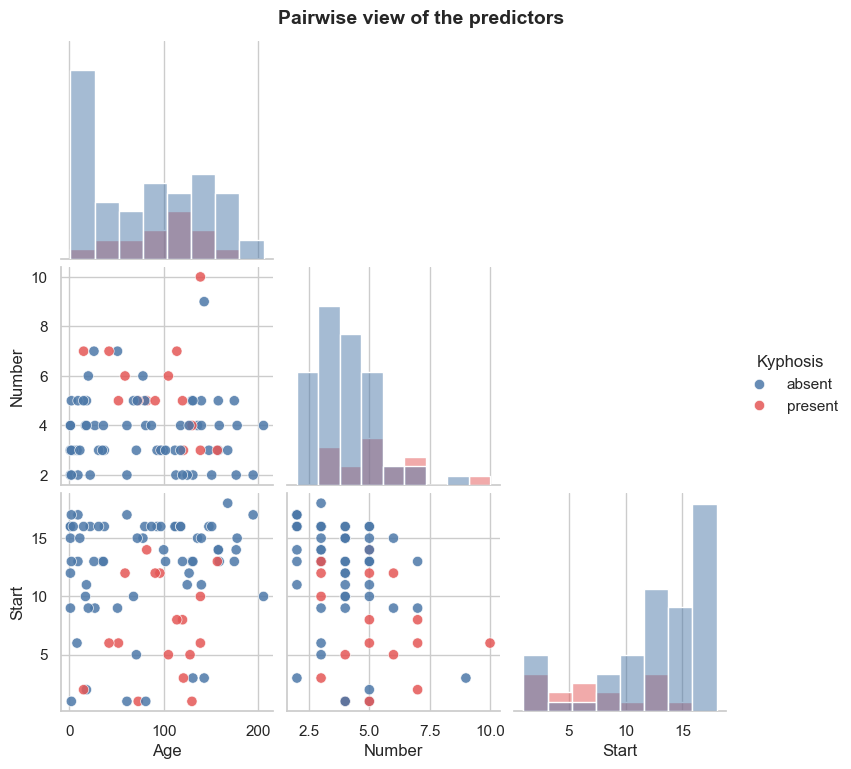

In [4]:
pairplot = sns.pairplot(
    df,
    hue=target,
    hue_order=CLASS_ORDER,
    palette=CLASS_PALETTE,
    corner=True,
    diag_kind="hist",
    plot_kws={"s": 55, "alpha": 0.85, "edgecolor": "white", "linewidth": 0.5},
)
pairplot.fig.suptitle("Pairwise view of the predictors", y=1.02, fontsize=14, fontweight="bold")
plt.show()

**Answer.** The pairplot suggests that the classes are only partially separated in low-dimensional views. `Start` seems especially informative, while `Age` and `Number` also contribute, but there is still substantial overlap between the two classes.
## Task 2 - Train-test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

split_sizes = pd.DataFrame({
    "Set": ["Train", "Test"],
    "Size": [len(X_train), len(X_test)],
})

display(split_sizes)

,Set,Size
0,Train,56
1,Test,25


**Answer.** The lab asks for a 70:30 split, so the model is trained on 56 observations and tested on 25 observations. The split is stratified to preserve the original class imbalance in both subsets, which makes the train-test comparison more reliable on such a small dataset.

## Task 3 - Train a single decision tree

In [6]:
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

root_feature = features[dtree.tree_.feature[0]]
root_threshold = dtree.tree_.threshold[0]

tree_summary = pd.DataFrame(
    {
        "Value": [
            dtree.get_depth(),
            dtree.get_n_leaves(),
            root_feature,
            round(root_threshold, 2),
        ]
    },
    index=["Tree depth", "Leaves", "Root split feature", "Root threshold"],
)

display(tree_summary)

,Value
Tree depth,5
Leaves,12
Root split feature,Start
Root threshold,12.5


**Answer.** The fitted classifier is a standard CART decision tree using recursive binary splits. On this split, the learned tree has depth 5 with 12 leaves, and the root node first splits on `Start <= 12.5`. That first split already shows that the starting vertebra index is highly informative for postoperative outcome in this training sample.

## Task 4 - Prediction and evaluation

,precision,recall,f1-score,support
absent,0.857,0.90,0.878,20.0
present,0.500,0.40,0.444,5.0
accuracy,0.800,0.80,0.800,0.8
macro avg,0.679,0.65,0.661,25.0
weighted avg,0.786,0.80,0.791,25.0


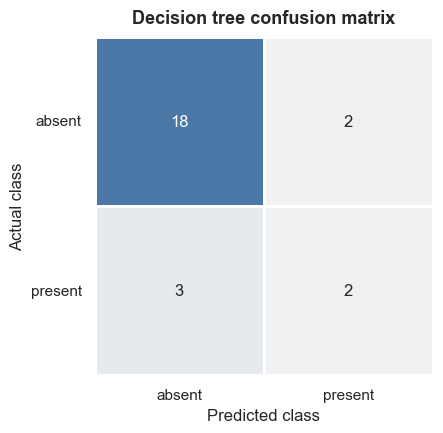

In [7]:
dtree_pred = dtree.predict(X_test)

dtree_metrics = report_frame(y_test, dtree_pred)
display(dtree_metrics.round(3))

fig, ax = plt.subplots(figsize=(5, 4.5))
plot_confusion(ax, y_test, dtree_pred, "Decision tree confusion matrix")
plt.tight_layout()
plt.show()

**Answer.** The decision tree reaches 0.80 test accuracy, but the classwise report is more informative than that single number. The model predicts the majority class `absent` well, yet recall for `present` is only 0.40, meaning that several postoperative kyphosis cases are missed.

## Task 5 - Tree visualization and interpretation

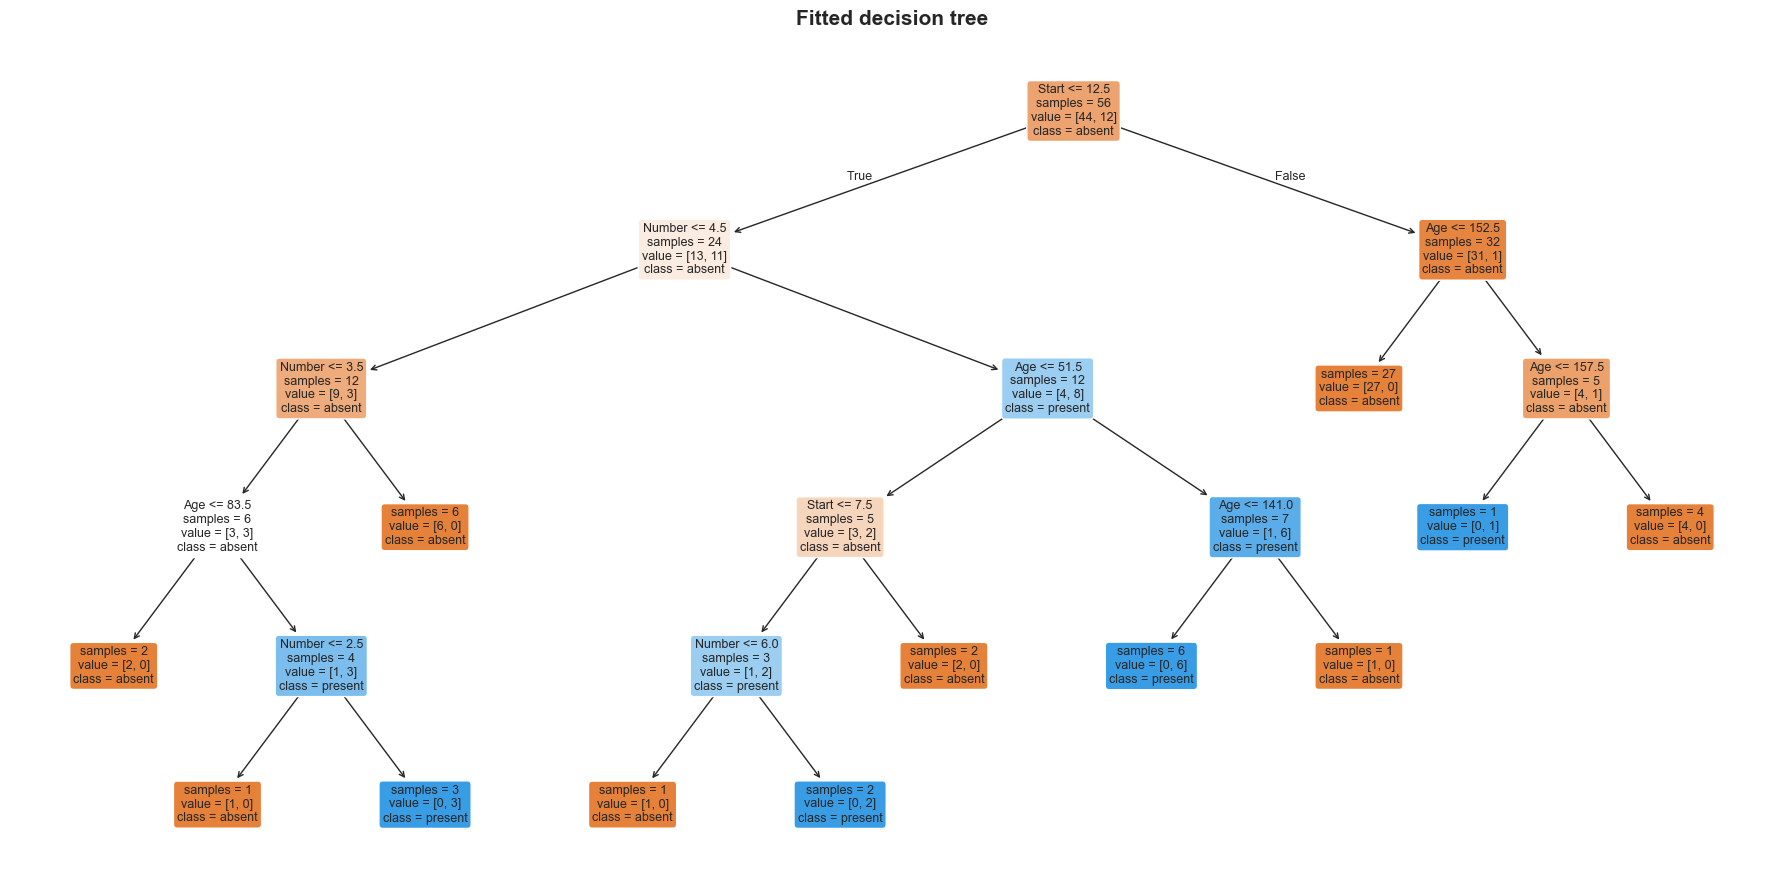

In [8]:
fig, ax = plt.subplots(figsize=(18, 9))
plot_tree(
    dtree,
    feature_names=features,
    class_names=dtree.classes_,
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=9,
    ax=ax,
)
ax.set_title("Fitted decision tree", fontsize=15, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

**Answer.** In each leaf, the displayed `value` gives the number of training observations from each class that reach that terminal node, ordered as `absent` then `present`. The predicted class of the leaf is simply the majority class inside that leaf. Each internal split is binary: observations satisfying the rule `feature <= threshold` move to the left branch, and the others move to the right branch. The split itself is chosen to reduce node impurity as much as possible, which in scikit-learn means minimizing the Gini impurity by default.

## Task 6 - Compare the decision tree with a random forest

,Model,Accuracy,Precision (present),Recall (present),F1 (present)
0,Decision tree,0.8,0.5,0.4,0.444
1,Random forest,0.8,0.5,0.4,0.444


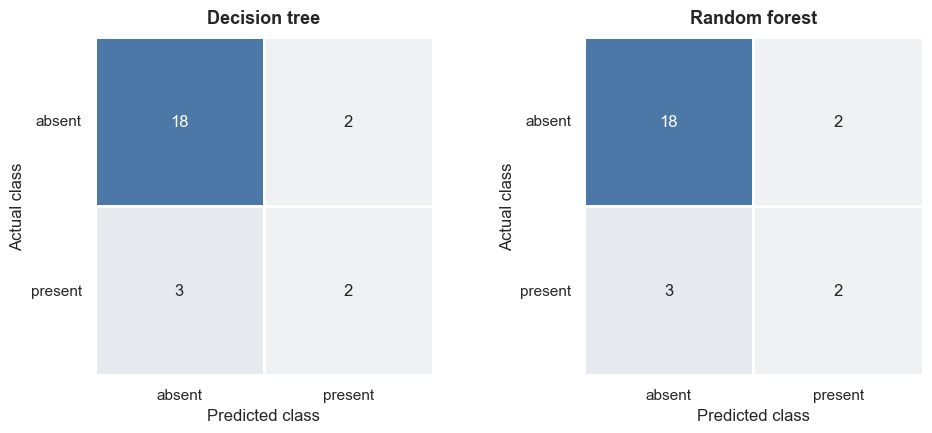

In [9]:
forest = RandomForestClassifier(n_estimators=300, random_state=42)
forest.fit(X_train, y_train)
forest_pred = forest.predict(X_test)

comparison = pd.DataFrame([
    summary_row("Decision tree", y_test, dtree_pred),
    summary_row("Random forest", y_test, forest_pred),
])

display(comparison.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
plot_confusion(axes[0], y_test, dtree_pred, "Decision tree")
plot_confusion(axes[1], y_test, forest_pred, "Random forest")
plt.tight_layout()
plt.show()

**Answer.** On this particular train-test split, the random forest does not improve the test metrics: it matches the decision tree with 0.80 accuracy and the same minority-class recall. Even so, the comparison is still instructive. A single tree is easy to interpret but has high variance, whereas a random forest averages many trees and is usually more stable. In a small dataset like this one, it is therefore completely plausible that the forest offers similar performance rather than a dramatic gain on one test split.

## Conclusion

A single decision tree is transparent and easy to visualize, but its predictions can be unstable and the minority class remains difficult to recover in this dataset. A random forest sacrifices interpretability, yet it typically improves stability by reducing variance through aggregation, even when the improvement is modest on one small test set.